# Speaker Role Tagging Evaluation

This notebook evaluates speaker role tagging accuracy by comparing predictions in `utterances_sample.csv` against ground truth labels in `utterances_sample_labeled.csv`.

In [1]:
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Load Data

Load both the predicted and labeled datasets.

In [2]:
# Load predicted speaker roles
df_pred = pd.read_csv('utterances_sample.csv')
print(f"Predicted data: {len(df_pred)} utterances")
print(f"Columns: {df_pred.columns.tolist()}")

# Load ground truth labels
df_true = pd.read_csv('utterances_sample_labeled.csv')
print(f"\nLabeled data: {len(df_true)} utterances")
print(f"Columns: {df_true.columns.tolist()}")

Predicted data: 2619 utterances
Columns: ['state', 'bid', 'hid', 'uid', 'pid', 'speaker.position', 'speaker.position.value', 'can_file_motions', 'is_presenter', 'relative_position', 'token_count', 'sent_count', 'mentions_speaker', 'mentions_bill', 'speech_act_cues', 'section_cues', 'section', 'text']

Labeled data: 2619 utterances
Columns: ['state', 'bid', 'hid', 'uid', 'pid', 'speaker.position', 'section', 'text']


In [3]:
# Display sample of predicted data
print("\nSample of predicted data:")
df_pred[['state', 'bid', 'hid', 'uid', 'pid', 'speaker.position']].head(10)


Sample of predicted data:


,state,bid,hid,uid,pid,speaker.position
0,CA,CA_201520160AB2050,255341,0,55,PRESIDING_CHAIR
1,CA,CA_201520160AB2050,255341,1,101330,BILL_AUTHOR
2,CA,CA_201520160AB2050,255341,2,55,PRESIDING_CHAIR
3,CA,CA_201520160AB2050,255341,3,101330,BILL_AUTHOR
4,CA,CA_201520160AB2050,255341,4,55,PRESIDING_CHAIR
5,CA,CA_201520160AB2050,255341,5,101330,BILL_AUTHOR
6,CA,CA_201520160AB2050,255341,6,55,PRESIDING_CHAIR
7,CA,CA_201520160AB2050,255341,7,152127,PUBLIC
8,CA,CA_201520160AB2050,255341,8,55,PRESIDING_CHAIR
9,CA,CA_201520160AB2050,255341,9,2851,PUBLIC


In [4]:
# Display sample of labeled data
print("Sample of labeled data:")
df_true[['state', 'bid', 'hid', 'uid', 'pid', 'speaker.position']].head(10)

Sample of labeled data:


,state,bid,hid,uid,pid,speaker.position
0,CA,CA_201520160AB2050,255341,0,55,PRESIDING_CHAIR
1,CA,CA_201520160AB2050,255341,1,101330,BILL_AUTHOR
2,CA,CA_201520160AB2050,255341,2,55,PRESIDING_CHAIR
3,CA,CA_201520160AB2050,255341,3,101330,BILL_AUTHOR
4,CA,CA_201520160AB2050,255341,4,55,PRESIDING_CHAIR
5,CA,CA_201520160AB2050,255341,5,101330,BILL_AUTHOR
6,CA,CA_201520160AB2050,255341,6,55,PRESIDING_CHAIR
7,CA,CA_201520160AB2050,255341,7,152127,PUBLIC
8,CA,CA_201520160AB2050,255341,8,55,PRESIDING_CHAIR
9,CA,CA_201520160AB2050,255341,9,2851,PUBLIC


## Merge and Align Data

Merge predicted and labeled datasets on utterance identifiers.

In [5]:
# Merge on utterance identifiers (state, bid, hid, uid)
df_merged = pd.merge(
    df_pred,
    df_true[['state', 'bid', 'hid', 'uid', 'speaker.position']],
    on=['state', 'bid', 'hid', 'uid'],
    suffixes=('_pred', '_true'),
    how='inner'
)

print(f"Merged dataset: {len(df_merged)} utterances")
print(f"\nColumns: {df_merged.columns.tolist()}")

# Check for any missing values in speaker position columns
print(f"\nMissing values:")
print(f"  Predicted: {df_merged['speaker.position_pred'].isna().sum()}")
print(f"  True: {df_merged['speaker.position_true'].isna().sum()}")

Merged dataset: 2619 utterances

Columns: ['state', 'bid', 'hid', 'uid', 'pid', 'speaker.position_pred', 'speaker.position.value', 'can_file_motions', 'is_presenter', 'relative_position', 'token_count', 'sent_count', 'mentions_speaker', 'mentions_bill', 'speech_act_cues', 'section_cues', 'section', 'text', 'speaker.position_true']

Missing values:
  Predicted: 0
  True: 0


In [6]:
# Remove rows with missing speaker positions
df_eval = df_merged.dropna(subset=['speaker.position_pred', 'speaker.position_true']).copy()
print(f"Evaluation dataset (after removing missing values): {len(df_eval)} utterances")

# Extract prediction and true label arrays
y_pred = df_eval['speaker.position_pred'].values
y_true = df_eval['speaker.position_true'].values

print(f"\nUnique predicted roles: {len(np.unique(y_pred))}")
print(f"Unique true roles: {len(np.unique(y_true))}")

Evaluation dataset (after removing missing values): 2619 utterances

Unique predicted roles: 8
Unique true roles: 7


## Speaker Role Distribution

In [7]:
# Count distribution of speaker roles
pred_counts = Counter(y_pred)
true_counts = Counter(y_true)

# Create comparison DataFrame
all_roles = sorted(set(list(pred_counts.keys()) + list(true_counts.keys())))
dist_df = pd.DataFrame({
    'Role': all_roles,
    'Predicted': [pred_counts.get(role, 0) for role in all_roles],
    'True': [true_counts.get(role, 0) for role in all_roles]
})

print("Speaker Role Distribution Comparison:")
print("=" * 80)
print(dist_df.to_string(index=False))
print("=" * 80)

Speaker Role Distribution Comparison:
            Role  Predicted  True
     BILL_AUTHOR        286   394
COMMITTEE_MEMBER        529   388
          EXPERT        147   244
      LEGISLATOR          0     2
   NONLEGISLATOR         25     0
           OTHER         30     0
 PRESIDING_CHAIR        841   941
          PUBLIC        626   514
       SECRETARY        135   136


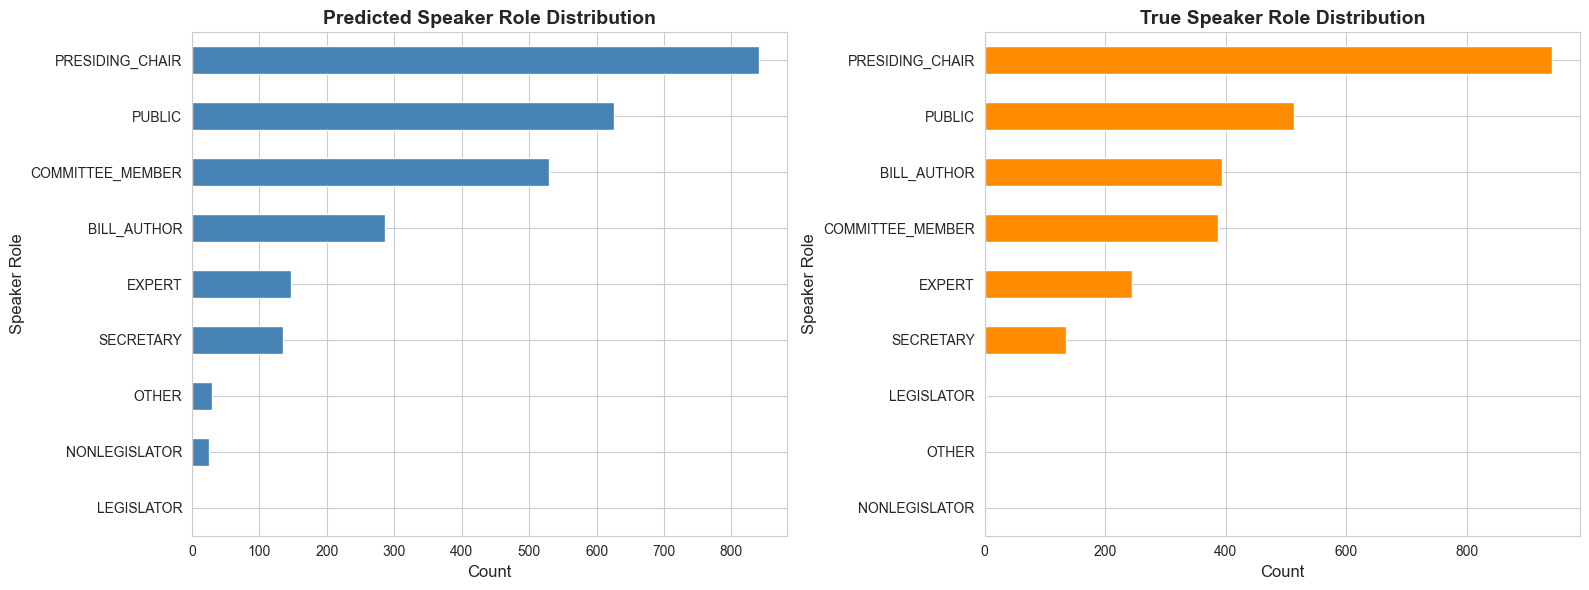

In [8]:
# Visualize distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted distribution
dist_df.set_index('Role')['Predicted'].sort_values(ascending=True).plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Predicted Speaker Role Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Speaker Role', fontsize=12)

# True distribution
dist_df.set_index('Role')['True'].sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='darkorange'
)
axes[1].set_title('True Speaker Role Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_ylabel('Speaker Role', fontsize=12)

plt.tight_layout()
plt.show()

## Overall Evaluation Metrics

In [9]:
# Calculate overall accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Calculate correct and incorrect predictions
correct = (y_pred == y_true).sum()
incorrect = (y_pred != y_true).sum()

print(f"\nCorrect predictions: {correct}/{len(y_true)}")
print(f"Incorrect predictions: {incorrect}/{len(y_true)}")

Overall Accuracy: 0.7782 (77.82%)

Correct predictions: 2038/2619
Incorrect predictions: 581/2619


In [10]:
# Generate classification report
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(y_true, y_pred, zero_division=0))


CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     BILL_AUTHOR       0.93      0.68      0.78       394
COMMITTEE_MEMBER       0.60      0.82      0.70       388
          EXPERT       0.52      0.31      0.39       244
      LEGISLATOR       0.00      0.00      0.00         2
   NONLEGISLATOR       0.00      0.00      0.00         0
           OTHER       0.00      0.00      0.00         0
 PRESIDING_CHAIR       0.94      0.84      0.89       941
          PUBLIC       0.72      0.87      0.79       514
       SECRETARY       0.99      0.99      0.99       136

        accuracy                           0.78      2619
       macro avg       0.52      0.50      0.50      2619
    weighted avg       0.81      0.78      0.78      2619



## Confusion Matrix

In [22]:
# Get unique labels for confusion matrix
labels = sorted(set(list(y_true) + list(y_pred)))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Create DataFrame for better visualization
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

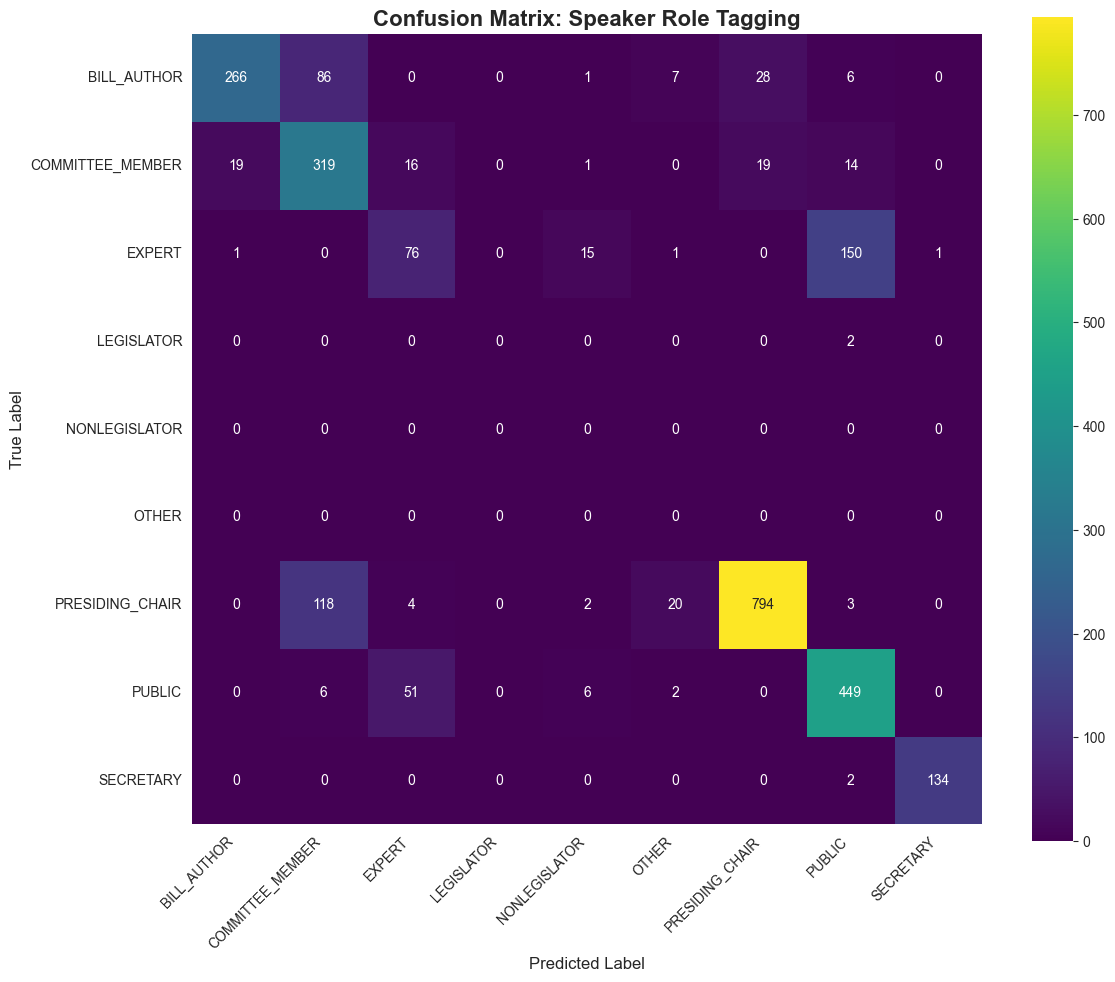

In [21]:
# Visualize confusion matrix as heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='viridis', cbar=True, 
            square=True)
plt.title('Confusion Matrix: Speaker Role Tagging', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Error Analysis

In [15]:
# Identify misclassified utterances
df_eval['correct'] = df_eval['speaker.position_pred'] == df_eval['speaker.position_true']
df_errors = df_eval[~df_eval['correct']].copy()

print(f"Total misclassifications: {len(df_errors)}")
print(f"\nMisclassification rate: {len(df_errors)/len(df_eval)*100:.2f}%")

Total misclassifications: 581

Misclassification rate: 22.18%


In [16]:
# Most common misclassification pairs
error_pairs = Counter(zip(df_errors['speaker.position_true'], df_errors['speaker.position_pred']))

print("\nTop 10 Most Common Misclassification Patterns:")
print("=" * 80)
print(f"{'True Role':<25} {'Predicted Role':<25} {'Count':<10}")
print("=" * 80)
for (true_role, pred_role), count in error_pairs.most_common(10):
    print(f"{true_role:<25} {pred_role:<25} {count:<10}")
print("=" * 80)


Top 10 Most Common Misclassification Patterns:
True Role                 Predicted Role            Count     
EXPERT                    PUBLIC                    150       
PRESIDING_CHAIR           COMMITTEE_MEMBER          118       
BILL_AUTHOR               COMMITTEE_MEMBER          86        
PUBLIC                    EXPERT                    51        
BILL_AUTHOR               PRESIDING_CHAIR           28        
PRESIDING_CHAIR           OTHER                     20        
COMMITTEE_MEMBER          PRESIDING_CHAIR           19        
COMMITTEE_MEMBER          BILL_AUTHOR               19        
COMMITTEE_MEMBER          EXPERT                    16        
EXPERT                    NONLEGISLATOR             15        


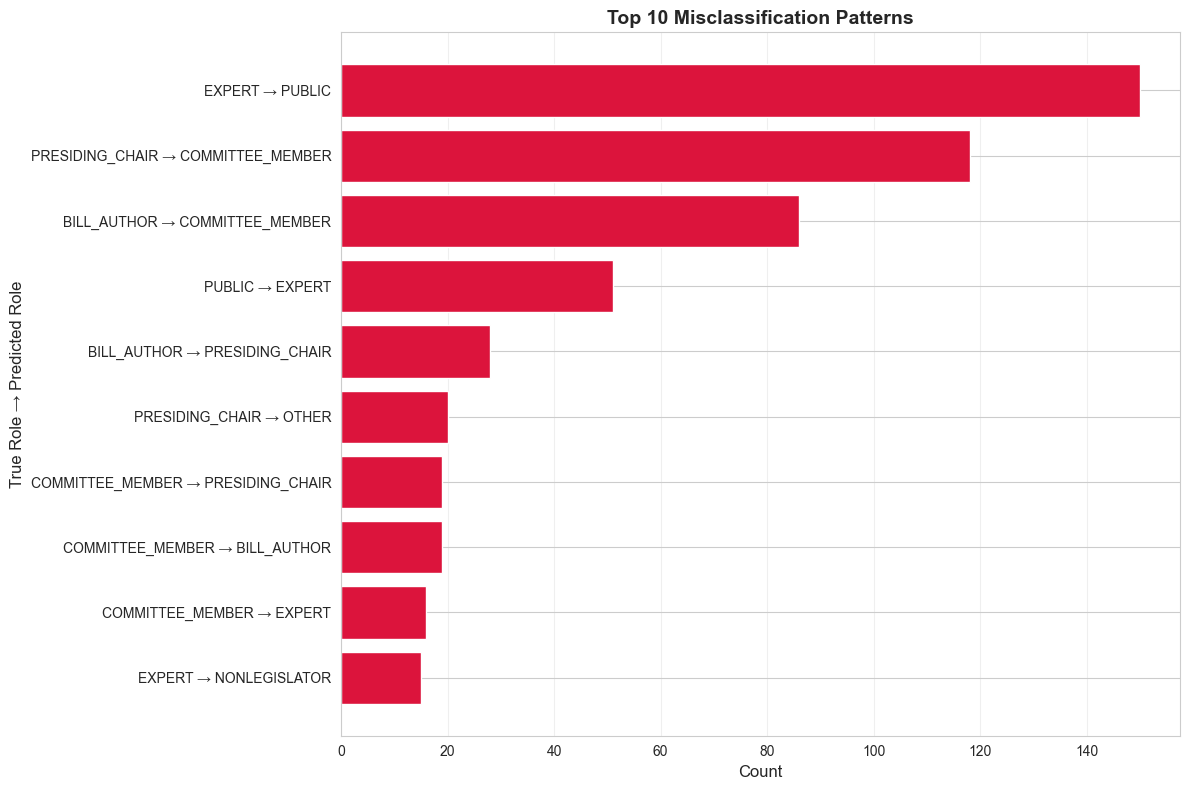

In [17]:
# Visualize top misclassification patterns
top_errors = error_pairs.most_common(10)
error_labels = [f"{true_role} → {pred_role}" for (true_role, pred_role), _ in top_errors]
error_counts = [count for _, count in top_errors]

plt.figure(figsize=(12, 8))
plt.barh(error_labels, error_counts, color='crimson')
plt.title('Top 10 Misclassification Patterns', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('True Role → Predicted Role', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Sample Misclassifications

Examine specific examples of misclassifications for qualitative analysis.

In [18]:
# Display sample misclassifications
print("Sample Misclassifications:")
print("=" * 80)

# Show a few examples from different error types
sample_errors = df_errors.head(10)

for idx, row in sample_errors.iterrows():
    print(f"\nUtterance ID: {row['uid']} (Hearing: {row['hid']}, Bill: {row['bid']})")
    print(f"True Role: {row['speaker.position_true']}")
    print(f"Predicted Role: {row['speaker.position_pred']}")
    if 'text' in row:
        text_preview = row['text'][:200] + '...' if len(str(row['text'])) > 200 else row['text']
        print(f"Text: {text_preview}")
    print("-" * 80)

Sample Misclassifications:

Utterance ID: 18 (Hearing: 255341, Bill: CA_201520160AB2050)
True Role: PRESIDING_CHAIR
Predicted Role: PUBLIC
Text: good morning NONLEGISLATOR on behalf of ORG ORG GPE all in support also here for western municipal water district who couldn't be here thank you
--------------------------------------------------------------------------------

Utterance ID: 26 (Hearing: 255341, Bill: CA_201520160AB2050)
True Role: PUBLIC
Predicted Role: OTHER
Text: thank you chair and members ORG for justice and accountability we have worked on the issue of safe drinking water in small communities for several years along with other people who will speak today an...
--------------------------------------------------------------------------------

Utterance ID: 33 (Hearing: 255341, Bill: CA_201520160AB2050)
True Role: BILL_AUTHOR
Predicted Role: OTHER
Text: well I would be force to speculate but my sense is that these are just very difficult to do and unless you have willing the